# Jaccard Similarity — Trainer/Client Matching Baseline
**VTC x RMIT AI Project COSC2667**

This notebook implements Jaccard similarity as a baseline matching method.
The idea is pretty simple, we look at what training styles and goals a client wants,
then see how much that overlaps with what each trainer actually offers.

We're not trying to build the final model here. This is just the baseline,
something to measure against once we build the actual AI matching system later.

Data source: `pt_matching_dataset.xlsx` (provided by VTC)

## Quick explanation of Jaccard similarity

Jaccard similarity just measures the overlap between two sets:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

So if a client wants `{Yoga, Boxing, Strength}` and a trainer offers `{Yoga, Strength, Pilates}`:
- Intersection = `{Yoga, Strength}` → 2 items in common
- Union = `{Yoga, Boxing, Strength, Pilates}` → 4 items total
- Jaccard = 2/4 = **0.5**

Scores go from 0 (nothing in common) to 1 (exact same set).

We run this separately for training styles and for goal tags, then combine them into one score.

In [62]:
import pandas as pd          # For handling data tables
import numpy as np           # For numerical operations
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns        # For better-looking visualizations
pd.set_option('display.max_columns', None)  # Show all columns when displaying data
!pip install pandoc

## Load the data

The Excel file has three sheets. The one we care about are Client Profiles and Trainer Profiles.
Worth noting, the first row in each sheet is actually a title, not the column headers.
So we need `header=1` to skip it, otherwise pandas reads the column names wrong.

In [16]:
FILE = 'pt_matching_dataset.xlsx'
# FILE = r'C:\Users\asus\Downloads\pt_matching_dataset.xlsx'

clients  = pd.read_excel(FILE, sheet_name='Client Profiles',  header=1)
trainers = pd.read_excel(FILE, sheet_name='Trainer Profiles', header=1)

print('Clients shape: ', clients.shape)
print('Trainers shape:', trainers.shape)

Clients shape:  (25, 17)
Trainers shape: (25, 18)


In [18]:
# quick look at what we have
clients.head(3)

,Client ID,Name,Age,Gender,Preferred Training Type,Gender Pref,Gender Pref Hard,Styles Desired,Goal Tags,Education Pref,Education Importance,Priority: Gender,Priority: Style,Priority: Avail,Priority: Qual,Location City,Radius (km)
0,CLT-1001,Alex Miller,56,male,in_person,female,True,"Yoga, Strength","injury_recovery, body_composition, muscle_gain",Doctorate,medium,0.7,1.0,1.5,1.5,Hobart,10.0
1,CLT-1002,Jordan Walsh,61,male,in_person,female,True,"Boxing, Yoga, Functional Training, CrossFit",body_composition,High School,medium,1.0,1.0,0.7,1.0,Wollongong,5.0
2,CLT-1003,Sam Thomas,52,male,in_person,male,False,"Functional Training, Powerlifting",sports_performance,Associate,low,1.5,0.7,1.5,1.0,Hobart,10.0


In [20]:
trainers.head(3)

,Trainer ID,Name,Gender,Training Type,Age Ranges Served,Styles Offered,Goal Tags,Education Level,Experience (yrs),Personality Traits,Qualifications,Approval Status,Bio,Location,City,Radius (km),Recency Loc Timestamp,VTC Featured
0,TRN-2001,Kai Jones,female,online,"[0,18), [18,25), [35,50), [50,65)","Pilates, Yoga, Functional Training, Strength","weight_loss, sports_performance, body_composit...",Higher Education,6,"Patient, Motivating","ASCA Level 3, Level 1 Sports Nutrition",approved,Passionate about helping everyday people reach...,Canberra,Canberra,NaN,NaN,False
1,TRN-2002,Zoe Smith,female,both,"[35,50), [65,100)","Running, CrossFit","injury_recovery, body_composition, healthy_agi...",Diploma of Fitness,9,"Humorous, Friendly, Patient","CrossFit L1, Level 2 Sports Nutrition, Diploma...",approved,Specialising in strength and conditioning with...,Darwin,Darwin,10.0,2026-03-20,False
2,TRN-2003,Liam Ryan,female,in_person,"[18,25), [35,50), [50,65)","Functional Training, Cardio","injury_recovery, muscle_gain",Certificate III in Fitness,20,"Challenging, Humorous, Supportive","CrossFit L1, Level 2 Sports Nutrition, Older A...",pending,Yoga and mindfulness coach dedicated to buildi...,Adelaide,Adelaide,5.0,2026-03-16,False


## Parse the style and goal columns into sets

The styles and goals in the spreadsheet are stored as comma-separated strings like
`"Yoga, Strength, Boxing"`. Jaccard works on Python sets, so we need to split them up first.

We also lowercase everything so `"Yoga"` and `"yoga"` don't count as different things.

In [25]:
def to_set(val):
    # handles NaN gracefully — just return an empty set
    if pd.isna(val) or str(val).strip() == '':
        return set()
    return {item.strip().lower() for item in str(val).split(',')}


clients['styles_set'] = clients['Styles Desired'].apply(to_set)
clients['goals_set']  = clients['Goal Tags'].apply(to_set)

trainers['styles_set'] = trainers['Styles Offered'].apply(to_set)
trainers['goals_set']  = trainers['Goal Tags'].apply(to_set)

# sanity check
print('Example client styles:', clients.loc[0, 'styles_set'])
print('Example client goals: ', clients.loc[0, 'goals_set'])

Example client styles: {'strength', 'yoga'}
Example client goals:  {'muscle_gain', 'injury_recovery', 'body_composition'}


## Hard filters

Before we score anything, we need to remove trainers that are incompatible with a client.

The three hard filters are:
1. Trainer approval status must be `approved` (pending/rejected trainers don't appear in results)
2. If a client's gender preference is marked as hard (`Gender Pref Hard = True`), the trainer's gender must match
3. The training type (online / in-person / both) must be compatible

In [28]:
def types_compatible(client_type, trainer_type):
    # if either side says 'both' they're flexible — always compatible
    # if data is missing, don't block the match
    if pd.isna(client_type) or pd.isna(trainer_type):
        return True
    c = str(client_type).strip().lower()
    t = str(trainer_type).strip().lower()
    return c == 'both' or t == 'both' or c == t


def passes_filters(client_row, trainer_row):
    # check 1 — trainer must be approved
    if str(trainer_row['Approval Status']).strip().lower() != 'approved':
        return False

    # check 2 — hard gender preference
    if str(client_row['Gender Pref Hard']).strip().lower() == 'true':
        pref   = str(client_row['Gender Pref']).strip().lower()
        gender = str(trainer_row['Gender']).strip().lower()
        if pref not in ('null', 'nan', '') and pref != gender:
            return False

    # check 3 — training type
    if not types_compatible(client_row['Preferred Training Type'], trainer_row['Training Type']):
        return False

    return True

## The Jaccard function


In [31]:
def jaccard(set_a, set_b):
    # if both sets are empty there's nothing to compare
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


# quick test to make sure it works
a = {'yoga', 'strength', 'boxing'}
b = {'yoga', 'strength', 'pilates'}
print(f'Sets: {a}  vs  {b}')
print(f'Jaccard: {jaccard(a, b):.2f}')  # should be 0.50

Sets: {'strength', 'boxing', 'yoga'}  vs  {'strength', 'yoga', 'pilates'}
Jaccard: 0.50


## Scoring a client–trainer pair

We compute Jaccard on styles and Jaccard on goals separately, then combine them.

The client data already has a `Priority: Style` column with weights (0.7 = low, 1.0 = medium, 1.5 = high).
We use that to weight the style score differently per client. Goals get a fixed weight of 1.0 since
there's no separate priority for them in the dataset.

Final score = weighted average of both Jaccard scores.

In [34]:
def score_match(client_row, trainer_row):
    # first check hard filters — return None if they fail
    if not passes_filters(client_row, trainer_row):
        return None

    j_styles = jaccard(client_row['styles_set'], trainer_row['styles_set'])
    j_goals  = jaccard(client_row['goals_set'],  trainer_row['goals_set'])

    # pull the style priority weight from the client row
    w_style = float(client_row['Priority: Style']) if pd.notna(client_row['Priority: Style']) else 1.0
    w_goal  = 1.0

    score = (w_style * j_styles + w_goal * j_goals) / (w_style + w_goal)

    return {
        'client_id'   : client_row['Client ID'],
        'trainer_id'  : trainer_row['Trainer ID'],
        'trainer_name': trainer_row['Name'],
        'j_styles'    : round(j_styles, 4),
        'j_goals'     : round(j_goals,  4),
        'final_score' : round(score,    4)
    }

## Run all the pairs

Loop over every client–trainer combination, score them, collect results.

In [37]:
results = []

for _, client in clients.iterrows():
    for _, trainer in trainers.iterrows():
        pair = score_match(client, trainer)
        if pair is not None:
            results.append(pair)

scores_df = pd.DataFrame(results)

total    = len(clients) * len(trainers)
eligible = len(scores_df)

print(f'Total pairs: {total}')
print(f'After hard filters: {eligible} ({total - eligible} blocked)')
print()
scores_df.head()

Total pairs: 625
After hard filters: 259 (366 blocked)



,client_id,trainer_id,trainer_name,j_styles,j_goals,final_score
0,CLT-1001,TRN-2002,Zoe Smith,0.0,0.3333,0.1667
1,CLT-1001,TRN-2004,Nadia Burke,0.0,0.2500,0.1250
2,CLT-1001,TRN-2006,Isla Taylor,0.2,0.0000,0.1000
3,CLT-1001,TRN-2010,Grace Burke,0.0,0.0000,0.0000
4,CLT-1001,TRN-2017,Aiden Clark,0.2,0.3333,0.2667


## Get top-N trainer recommendations per client

In [40]:
TOP_N = 5

top_matches = (
    scores_df
    .sort_values('final_score', ascending=False)
    .groupby('client_id')
    .head(TOP_N)
    .reset_index(drop=True)
)

top_matches['rank'] = top_matches.groupby('client_id').cumcount() + 1

top_matches[['client_id', 'rank', 'trainer_id', 'trainer_name', 'j_styles', 'j_goals', 'final_score']].head(10)

,client_id,rank,trainer_id,trainer_name,j_styles,j_goals,final_score
0,CLT-1021,1,TRN-2001,Kai Jones,0.3333,0.8000,0.6078
1,CLT-1023,1,TRN-2007,Felix Williams,0.3333,0.7500,0.5417
2,CLT-1019,1,TRN-2009,Noah Jones,0.2000,0.7500,0.5235
3,CLT-1022,1,TRN-2014,Ella Murphy,0.1429,0.6667,0.4510
4,CLT-1019,2,TRN-2019,Eli Miller,0.5000,0.4000,0.4412
5,CLT-1007,1,TRN-2018,Ruby White,0.2000,0.6667,0.4333
6,CLT-1005,1,TRN-2006,Isla Taylor,0.6000,0.1667,0.4267
7,CLT-1015,1,TRN-2017,Aiden Clark,0.2500,0.6000,0.4250
8,CLT-1011,1,TRN-2011,Leon Murphy,0.2500,0.6667,0.4167
9,CLT-1010,1,TRN-2011,Leon Murphy,0.2500,0.6667,0.4167


In [42]:
# helper to look at a specific client's matches in a readable way
def show_matches(client_id):
    c = clients[clients['Client ID'] == client_id].iloc[0]
    print(f"{client_id} — {c['Name']}")
    print(f"  Wants : {c['Preferred Training Type']} | {c['Styles Desired']}")
    print(f"  Goals : {c['Goal Tags']}")
    print(f"  Gender pref: {c['Gender Pref']} (hard = {c['Gender Pref Hard']})")
    print()

    matches = top_matches[top_matches['client_id'] == client_id]
    for _, row in matches.iterrows():
        t = trainers[trainers['Trainer ID'] == row['trainer_id']].iloc[0]
        print(f"  #{int(row['rank'])}  {row['trainer_id']} {row['trainer_name']}")
        print(f"       Offers: {t['Styles Offered']}")
        print(f"       Goals : {t['Goal Tags']}")
        print(f"       Style Jaccard={row['j_styles']:.2f}  Goal Jaccard={row['j_goals']:.2f}  Score={row['final_score']:.2f}")
        print()


show_matches('CLT-1001')

CLT-1001 — Alex Miller
  Wants : in_person | Yoga, Strength
  Goals : injury_recovery, body_composition, muscle_gain
  Gender pref: female (hard = True)

  #1  TRN-2020 Ivy Singh
       Offers: HIIT, Powerlifting, Running, Cardio, Strength
       Goals : muscle_gain, weight_loss, injury_recovery, sports_performance
       Style Jaccard=0.17  Goal Jaccard=0.40  Score=0.28

  #2  TRN-2017 Aiden Clark
       Offers: Running, Yoga, Powerlifting, Functional Training
       Goals : strength, general_fitness, body_composition, flexibility, injury_recovery
       Style Jaccard=0.20  Goal Jaccard=0.33  Score=0.27

  #3  TRN-2018 Ruby White
       Offers: Strength, Sports Performance, Bodybuilding
       Goals : muscle_gain, strength
       Style Jaccard=0.25  Goal Jaccard=0.25  Score=0.25

  #4  TRN-2002 Zoe Smith
       Offers: Running, CrossFit
       Goals : injury_recovery, body_composition, healthy_aging, general_fitness, flexibility
       Style Jaccard=0.00  Goal Jaccard=0.33  Score=0.17

In [46]:
#2
show_matches('CLT-1002')

CLT-1002 — Jordan Walsh
  Wants : in_person | Boxing, Yoga, Functional Training, CrossFit
  Goals : body_composition
  Gender pref: female (hard = True)

  #1  TRN-2017 Aiden Clark
       Offers: Running, Yoga, Powerlifting, Functional Training
       Goals : strength, general_fitness, body_composition, flexibility, injury_recovery
       Style Jaccard=0.33  Goal Jaccard=0.20  Score=0.27

  #2  TRN-2002 Zoe Smith
       Offers: Running, CrossFit
       Goals : injury_recovery, body_composition, healthy_aging, general_fitness, flexibility
       Style Jaccard=0.20  Goal Jaccard=0.20  Score=0.20

  #3  TRN-2022 Sara Miller
       Offers: Boxing, HIIT
       Goals : weight_loss, flexibility, sports_performance
       Style Jaccard=0.20  Goal Jaccard=0.00  Score=0.10

  #4  TRN-2010 Grace Burke
       Offers: Cardio, Boxing
       Goals : weight_loss, sports_performance
       Style Jaccard=0.20  Goal Jaccard=0.00  Score=0.10

  #5  TRN-2004 Nadia Burke
       Offers: HIIT, Functional Trai

## Visualisations

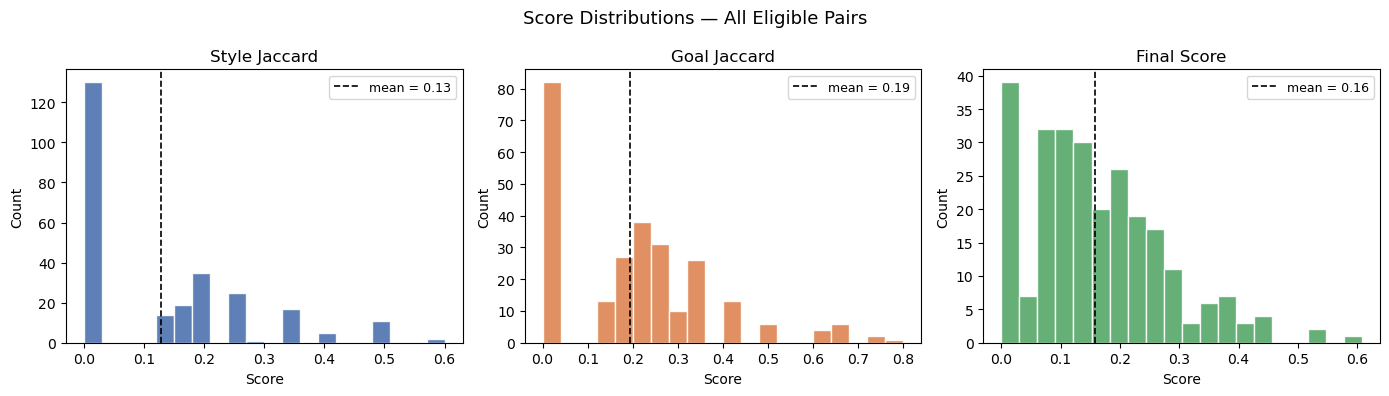

In [49]:
# distribution of all three score types
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Score Distributions — All Eligible Pairs', fontsize=13)

cols   = ['j_styles', 'j_goals', 'final_score']
titles = ['Style Jaccard', 'Goal Jaccard', 'Final Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, title, color in zip(axes, cols, titles, colors):
    ax.hist(scores_df[col], bins=20, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(scores_df[col].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean = {scores_df[col].mean():.2f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('score_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

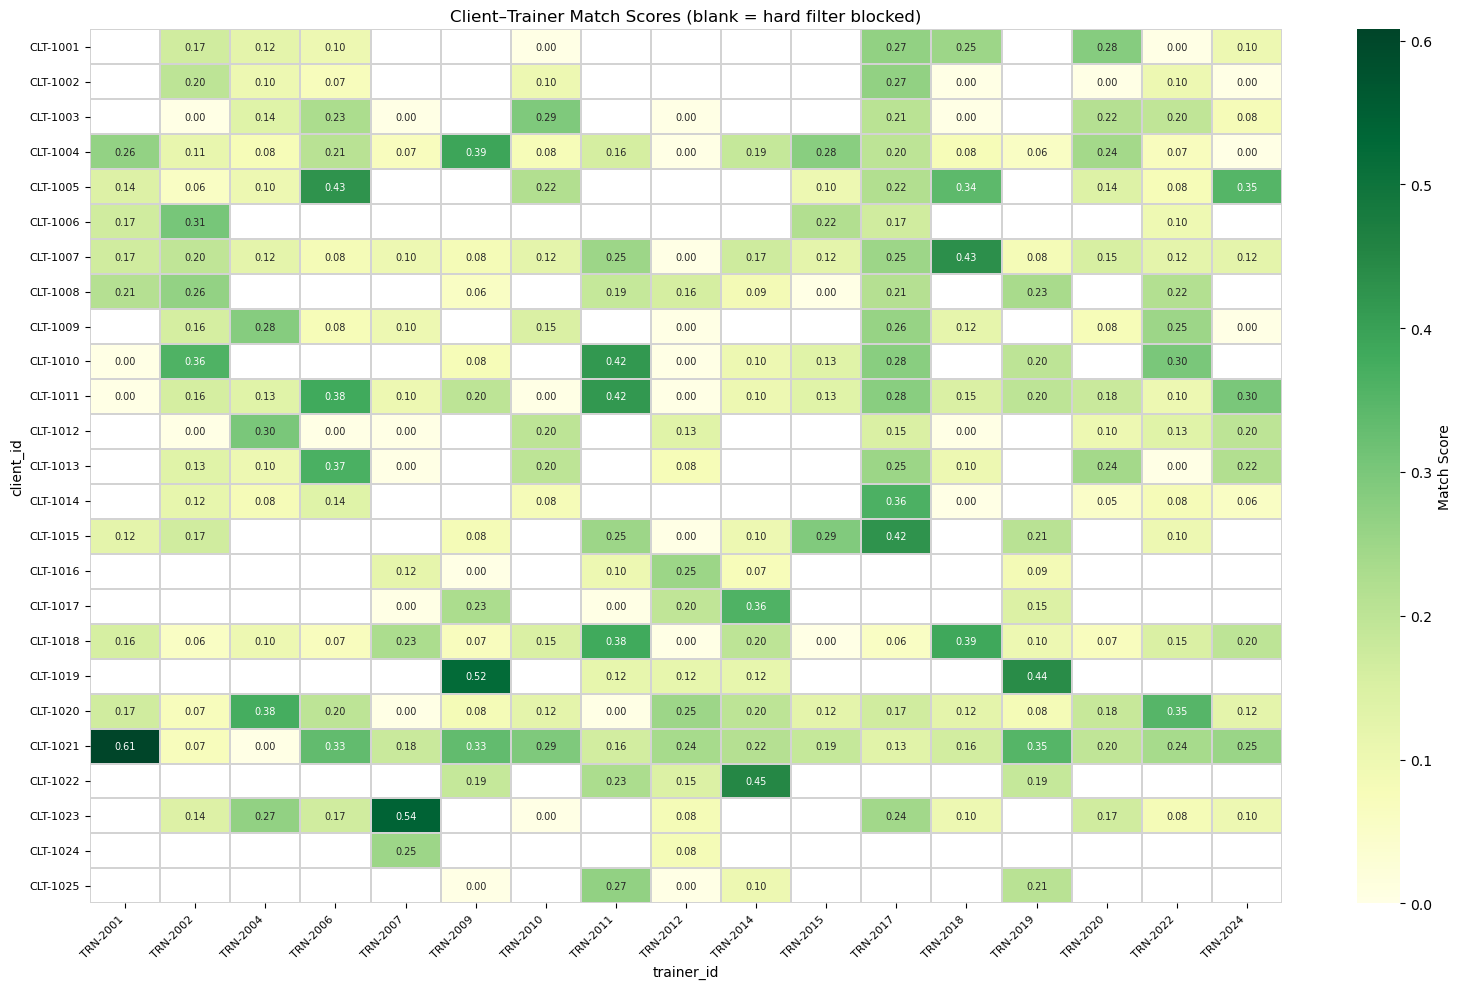

In [51]:
# heatmap — shows at a glance which clients have good options vs limited options
# NaN cells = blocked by hard filter
matrix = scores_df.pivot(index='client_id', columns='trainer_id', values='final_score')

plt.figure(figsize=(16, 10))
sns.heatmap(
    matrix,
    cmap='YlGn',
    annot=True,
    fmt='.2f',
    linewidths=0.3,
    linecolor='lightgrey',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Match Score'}
)
plt.title('Client–Trainer Match Scores (blank = hard filter blocked)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('match_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

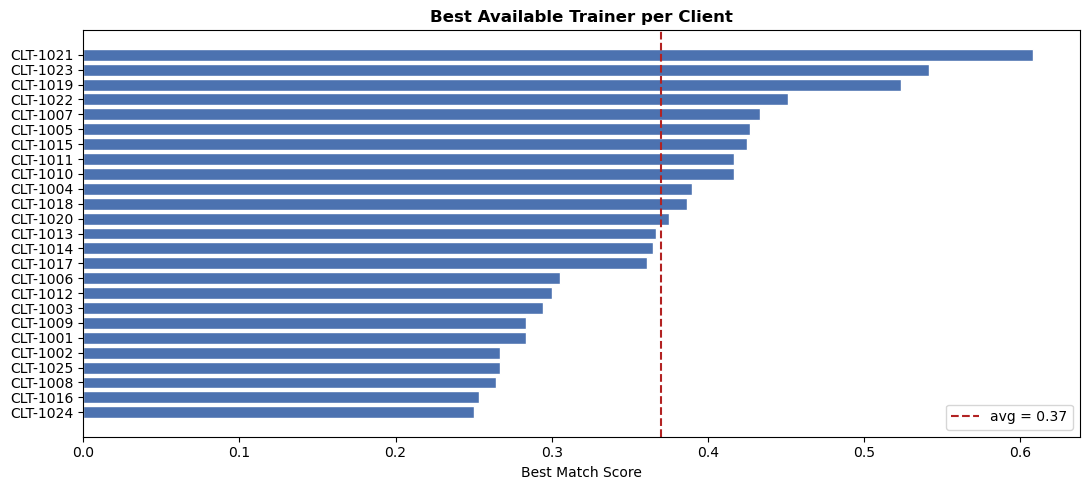

In [53]:
# best available match score per client — useful for spotting clients that are hard to match
best_per_client = (
    top_matches[top_matches['rank'] == 1]
    .set_index('client_id')['final_score']
    .sort_values()
)

plt.figure(figsize=(11, 5))
plt.barh(best_per_client.index, best_per_client.values, color='#4C72B0', edgecolor='white')
plt.axvline(best_per_client.mean(), color='firebrick', linestyle='--', linewidth=1.5,
            label=f'avg = {best_per_client.mean():.2f}')
plt.xlabel('Best Match Score')
plt.title('Best Available Trainer per Client', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('best_match_per_client.png', dpi=120, bbox_inches='tight')
plt.show()

In [64]:
# export for laterr comparison
scores_df.to_csv(r'C:\Users\asus\Downloads\jaccard_all_scores.csv', index=False)
top_matches.to_csv(r'C:\Users\asus\Downloads\jaccard_top_matches.csv', index=False)

print('Saved: jaccard_all_scores.csv, jaccard_top_matches.csv')

Saved: jaccard_all_scores.csv, jaccard_top_matches.csv


Jaccard is purely label matching, it only scores 1 when two strings are exactly the same. It has no concept of meaning.

For example:

A client says "weight_loss", a trainer offers "fat_reduction" → Jaccard = 0 (treats them as totally different)
A client's bio says "I want someone who keeps me accountable", a trainer's bio says "I hold my clients to high standards" → Jaccard can't compare these at all
That's where the semantic similarity approach (using the other dataset your groupmate made) comes in. Instead of matching exact labels, embeddings capture the meaning of text, so similar-meaning phrases score high even if the words are different.